In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"

In [3]:
df = pd.read_csv(f'{DATA_DIR}/v1/function_dataset_cleaned.csv')

In [4]:
X = df.drop(columns=['label'])
y = df['label']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

## 特徵工程

In [6]:
# 先將原本100個欄位拿去訓練模型
best_model = joblib.load(f'{MODEL_DIR}/v1/best_model.joblib')
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [8]:
print("原始特徵:")
print(f"準確度: {accuracy:.4f}")
print(f"混淆矩陣:\n{confusion_matrix(y_test, y_pred)}\n")
print(f"分類報告:\n{classification_report(y_test, y_pred)}")

原始特徵:
準確度: 0.6963
混淆矩陣:
[[36  0  1  0  1  0 13 49]
 [ 0 96  2  0  0  2  0  0]
 [ 1  1 70 12 11  5  0  0]
 [ 0  0  6 65 23  0  4  2]
 [ 6  0  2 21 67  0  2  2]
 [ 0  1  5  2  8 84  0  0]
 [ 0  0  0  0  0  0 99  1]
 [51  0  1  0  1  0  7 40]]

分類報告:
              precision    recall  f1-score   support

      cosine       0.38      0.36      0.37       100
       cubic       0.98      0.96      0.97       100
 exponential       0.80      0.70      0.75       100
      linear       0.65      0.65      0.65       100
 logarithmic       0.60      0.67      0.64       100
   quadratic       0.92      0.84      0.88       100
  reciprocal       0.79      0.99      0.88       100
        sine       0.43      0.40      0.41       100

    accuracy                           0.70       800
   macro avg       0.70      0.70      0.69       800
weighted avg       0.70      0.70      0.69       800



In [9]:
# 將原始資料標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 訓練集

In [10]:
train_first_diff = np.diff(X_train.values, axis=1)          # 一階差分
train_second_diff = np.diff(X_train.values, n=2, axis=1)    # 二階差分
train_amplitude = X_train.max(axis=1) - X_train.min(axis=1) # 變化總幅度

train_x = np.linspace(-2, 2, X_train.shape[1]).reshape(-1, 1)
train_slopes = []                                           # 每一筆函數的整體迴歸斜率
for row in X_train.values:
    train_model = LinearRegression()
    train_model.fit(train_x, row)
    train_slopes.append(train_model.coef_[0])
train_slopes = np.array(train_slopes)

In [11]:
print(X_train_scaled.shape)     # 訓練數據的形狀

(3200, 100)


In [12]:
print(f"原始最大值:\n{X_train.max(axis=0)}\n")              # 最大值
print(f"標準化後的最大值:\n{X_train_scaled.max(axis=0)}\n")

原始最大值:
y_00    24266.438981
y_01    19732.759452
y_02    16430.824383
y_03    13518.223276
y_04    10970.672742
            ...     
y_95     7485.792625
y_96     9141.680258
y_97    11056.356401
y_98    13114.510942
y_99    16160.561476
Length: 100, dtype: float64

標準化後的最大值:
[24.18019544 23.84252833 23.76686464 23.45849832 23.34317981 23.41792642
 21.96532924 22.55662888 20.73179451 22.6950199  21.63036928 21.33757276
 22.65914184 20.45927304 17.92231739 17.06295295 17.40634285 14.8309269
 18.54748372 21.57708753 13.27498884 19.4570758  15.03473195 16.27011947
 17.43301287 28.52363386 11.75604073 29.19690528 34.86288693 17.22252768
  3.76716776 19.2077311  24.52897835 20.4639621  26.51895963 31.78274756
 31.53378151 19.93077756 24.24886801 26.4578899  14.75868478 21.62574222
 32.00104372 28.78497338 25.57980822 31.61266949 23.47342279 18.82282096
 29.48818422 30.50770479 24.6969746  28.92146254 10.28225203 20.50269403
 33.72500349 35.80532542 16.53113781 22.97359997 26.70502622 22.115

In [13]:
print(f"原始最小值:\n{X_train.min(axis=0)}\n")              # 最小值
print(f"標準化後的最小值:\n{X_train_scaled.min(axis=0)}\n")

原始最小值:
y_00   -27081.261540
y_01   -21953.501756
y_02   -18445.342331
y_03   -15235.740581
y_04   -11677.397823
            ...     
y_95    -9270.747167
y_96   -11850.694691
y_97   -14682.582507
y_98   -18133.768760
y_99   -21538.162212
Length: 100, dtype: float64

標準化後的最小值:
[-27.01094717 -26.55277108 -26.70818192 -26.46627211 -24.87680022
 -25.15707354 -24.42004874 -23.78037188 -26.06486997 -25.0257666
 -21.60415542 -26.40271912 -22.9097689  -25.29854957 -26.21652758
 -22.16647438 -22.68285307 -25.91559055 -16.92444167 -10.44920079
 -36.96843922 -26.33175141 -27.50470629 -11.80496604 -19.81981118
 -14.54350963 -35.70917045 -16.69485653 -28.30062197 -34.90125869
 -46.75496029 -26.08983728 -21.32903804 -17.0264929  -34.98394349
  -8.47243576 -14.03266053 -32.22815766 -19.99503882 -15.90608438
 -23.90543369 -35.71240058 -10.49037172 -26.12378086  -7.2503067
 -20.09658415 -20.28379456 -42.73380704 -12.38597922 -26.44489681
 -18.44436976 -23.62099849 -44.14821407 -25.02090351 -19.18808256

In [14]:
print(X_train.mean(axis=0))     # 原始平均值

y_00    12.293230
y_01    10.565604
y_02     8.905237
y_03     7.398751
y_04     6.794630
          ...    
y_95     1.614899
y_96     1.733946
y_97     2.432776
y_98     2.709469
y_99     3.492007
Length: 100, dtype: float64


In [15]:
print(X_train.std(axis=0))      # 原始標準差

y_00    1003.215065
y_01     827.314783
y_02     691.066572
y_03     576.035853
y_04     469.755693
           ...     
y_95     442.668828
y_96     543.167584
y_97     647.818684
y_98     780.008971
y_99     934.602555
Length: 100, dtype: float64


In [16]:
print(train_slopes[:5])         # 迴歸斜率(取前5筆資料)

[ 3.93527743e+01  2.75982264e-02 -5.17612457e+02 -3.78744971e+00
  1.06275994e+00]


In [17]:
print("經過一階差分處理後的結果:(取前5筆資料)")
train_first_diff_mean = train_first_diff.mean(axis=1)
train_first_diff_std = train_first_diff.std(axis=1)
print(f"平均值:\n{train_first_diff_mean[:5]}")
print(f"標準差:\n{train_first_diff_std[:5]}\n")

經過一階差分處理後的結果:(取前5筆資料)
平均值:
[ 2.71096822e+00  8.39340277e-04 -6.37767124e+01 -1.53882985e-01
  3.67497285e-02]
標準差:
[6.38390606e+00 1.72462378e-01 1.88575188e+02 1.02125988e+00
 7.03259611e-01]



In [18]:
print("經過二階差分處理後的結果:(取前5筆資料)")
train_second_diff_mean = train_second_diff.mean(axis=1)
train_second_diff_std = train_second_diff.std(axis=1)
print(f"平均值:\n{train_second_diff_mean[:5]}")
print(f"標準差:\n{train_second_diff_std[:5]}\n")

經過二階差分處理後的結果:(取前5筆資料)
平均值:
[ 1.27405650e-01  2.31775004e-03  8.90205899e+00  1.18480929e-02
 -1.29479593e-02]
標準差:
[ 10.01813951   0.16747454 127.13299841   1.57073233   1.05872147]



In [19]:
print(train_amplitude[:5])      # 變化幅度:(取前5筆資料)

1025     268.385854
3173       2.445051
1817    6360.467951
959       29.475650
732       16.620751
dtype: float64


In [20]:
# 建立 X_train 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
train_math_features = pd.DataFrame({'slope': train_slopes,
                                    'amplitude': train_amplitude,
                                    'first_diff_mean': train_first_diff_mean,
                                    'first_diff_std': train_first_diff_std,
                                    'second_diff_mean': train_second_diff_mean,
                                    'second_diff_std': train_second_diff_std})

In [21]:
print(train_math_features.head())       # X_train數學特徵前5筆

           slope    amplitude  first_diff_mean  first_diff_std  \
1025   39.352774   268.385854         2.710968        6.383906   
3173    0.027598     2.445051         0.000839        0.172462   
1817 -517.612457  6360.467951       -63.776712      188.575188   
959    -3.787450    29.475650        -0.153883        1.021260   
732     1.062760    16.620751         0.036750        0.703260   

      second_diff_mean  second_diff_std  
1025          0.127406        10.018140  
3173          0.002318         0.167475  
1817          8.902059       127.132998  
959           0.011848         1.570732  
732          -0.012948         1.058721  


In [22]:
# 加入原始特徵
X_train_math = pd.concat([X_train.reset_index(drop=True),
                          train_math_features.reset_index(drop=True)], axis=1)

In [23]:
print(f"X_train_math 形狀: {X_train_math.shape}")

X_train_math 形狀: (3200, 106)


### 測試集

In [24]:
test_first_diff = np.diff(X_test.values, axis=1)            # 一階差分
test_second_diff = np.diff(X_test.values, n=2, axis=1)      # 二階差分
test_amplitude = X_test.max(axis=1) - X_test.min(axis=1)    # 變化總幅度

test_x = np.linspace(-2, 2, X_test.shape[1]).reshape(-1, 1)
test_slopes = []                                            # 每一筆函數的整體迴歸斜率
for row in X_test.values:
    test_model = LinearRegression()
    test_model.fit(test_x, row)
    test_slopes.append(test_model.coef_[0])
test_slopes = np.array(test_slopes)

# 一階差分統計
test_first_diff_mean = test_first_diff.mean(axis=1)
test_first_diff_std = test_first_diff.std(axis=1)
# 二階差分統計
test_second_diff_mean = test_second_diff.mean(axis=1)
test_second_diff_std = test_second_diff.std(axis=1)

In [25]:
# 建立 X_test 的6個數學特徵(斜率, 總變化量, 一階差分, 二階差分)
test_math_features = pd.DataFrame({'slope': test_slopes,
                                   'amplitude': test_amplitude,
                                   'first_diff_mean': test_first_diff_mean,
                                   'first_diff_std': test_first_diff_std,
                                   'second_diff_mean': test_second_diff_mean,
                                   'second_diff_std': test_second_diff_std})

In [26]:
print(test_math_features.head())        # X_test數學特徵前5筆

         slope  amplitude  first_diff_mean  first_diff_std  second_diff_mean  \
669   4.866466  20.017320         0.198276        0.423190          0.001309   
622   4.038724  39.395042         0.157066        1.024766         -0.029383   
2417 -3.650955  14.621966        -0.147697        0.135726          0.002918   
3925  0.143172   0.751684         0.007593        0.018721          0.000177   
2662 -0.033758   0.961365         0.003776        0.053073         -0.000160   

      second_diff_std  
669          0.685320  
622          1.259898  
2417         0.221368  
3925         0.029016  
2662         0.048248  


In [27]:
# 加入原始特徵
X_test_math = pd.concat([X_test.reset_index(drop=True),
                         test_math_features.reset_index(drop=True)], axis=1)

In [28]:
print(f"X_test_math 形狀: {X_test_math.shape}")

X_test_math 形狀: (800, 106)


### 把訓練集跟測試集結合成一個大表格

In [29]:
X_math_merged = pd.concat([X_train_math.reset_index(drop=True),
                           X_test_math.reset_index(drop=True)], axis=0)

In [30]:
print(X_math_merged.shape)      # 合併之後的形狀

(4000, 106)


### 將合併後的表格儲存成新的檔案

In [31]:
y_merged = pd.concat([y_train.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=0)

In [32]:
math_merged = pd.concat([y_merged, X_math_merged], axis=1)

In [33]:
math_merged.to_csv(f'{DATA_DIR}/v1/function_dataset_reset.csv', index=False)

### 標準化

In [34]:
scaler_after = StandardScaler()
X_train_math_scaled = scaler_after.fit_transform(X_train_math)
X_test_math_scaled = scaler_after.transform(X_test_math)

In [35]:
print("標準化之後:")
print(f"平均值:\n{X_train_math_scaled.mean(axis=0)}")
print(f"標準差:\n{X_train_math_scaled.std(axis=0)}")

標準化之後:
平均值:
[ 2.22044605e-18  2.22044605e-18  2.22044605e-18 -7.77156117e-18
  0.00000000e+00 -3.33066907e-18 -3.33066907e-18  2.22044605e-18
  2.22044605e-18 -4.44089210e-18 -1.66533454e-18 -6.66133815e-18
  3.33066907e-18 -5.55111512e-19 -1.11022302e-18  0.00000000e+00
  8.32667268e-18 -2.22044605e-18  2.22044605e-18  7.77156117e-18
  5.55111512e-18 -3.88578059e-18  6.66133815e-18  2.22044605e-18
  2.22044605e-18 -2.77555756e-18  6.10622664e-18 -4.44089210e-18
 -4.44089210e-18  2.22044605e-18  4.44089210e-18 -3.33066907e-18
 -4.44089210e-18  2.22044605e-18  1.11022302e-17 -4.44089210e-18
 -9.99200722e-18 -1.11022302e-18  1.11022302e-18 -1.11022302e-17
  8.88178420e-18  3.33066907e-18  1.11022302e-18  4.44089210e-18
 -3.33066907e-18  8.88178420e-18  0.00000000e+00  0.00000000e+00
 -6.66133815e-18  2.22044605e-18 -1.66533454e-18 -2.77555756e-18
 -8.88178420e-18  5.55111512e-18  2.22044605e-18  0.00000000e+00
  6.66133815e-18  0.00000000e+00 -4.44089210e-18  7.77156117e-18
 -2.22044605e

### 將結合後的數據再訓練模型一次

In [36]:
best_model_math = joblib.load(f'{MODEL_DIR}/v1/best_model.joblib')
best_model_math.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_pred_math = best_model_math.predict(X_test_math)
math_accuracy = accuracy_score(y_test.reset_index(drop=True), y_pred_math)

In [38]:
print("新增一些數學特徵之後:")
print(f"準確度: {math_accuracy:.4f}")
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), y_pred_math)}\n")
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), y_pred_math)}")

新增一些數學特徵之後:
準確度: 0.6950
混淆矩陣:
[[42  0  0  0  2  0  2 54]
 [ 0 96  3  0  0  1  0  0]
 [ 1  1 72 12 11  2  1  0]
 [ 1  0  3 59 32  0  3  2]
 [ 3  0  4 27 63  0  0  3]
 [ 0  0  4  3  8 85  0  0]
 [ 0  0  0  0  0  0 99  1]
 [55  0  0  0  2  0  3 40]]

分類報告:
              precision    recall  f1-score   support

      cosine       0.41      0.42      0.42       100
       cubic       0.99      0.96      0.97       100
 exponential       0.84      0.72      0.77       100
      linear       0.58      0.59      0.59       100
 logarithmic       0.53      0.63      0.58       100
   quadratic       0.97      0.85      0.90       100
  reciprocal       0.92      0.99      0.95       100
        sine       0.40      0.40      0.40       100

    accuracy                           0.69       800
   macro avg       0.70      0.70      0.70       800
weighted avg       0.70      0.69      0.70       800



### 比較結果

In [39]:
# 實驗結果
print(f"原始特徵準確度: {accuracy:.4f}")
print(f"數學特徵準確度: {math_accuracy:.4f}")
improvement = math_accuracy - accuracy
print(f"比原本特徵進步了: {improvement:+.4f}")
print("結論:", end=" ")
if improvement > 0:
    print("加入數學特徵後, 準確度提升。")
elif improvement < 0:
    print("加入數學特徵後, 準確度下降。")
else:
    print("加入數學特徵後, 準確度沒有改變。")

原始特徵準確度: 0.6963
數學特徵準確度: 0.6950
比原本特徵進步了: -0.0013
結論: 加入數學特徵後, 準確度下降。


## 特徵重要性

In [40]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [41]:
feature_importance = best_model_math.feature_importances_
feature_names = X_train_math.columns
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importance})

In [42]:
# 由高到低排序
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [43]:
print(importance_df.head(20).to_string(index=False, formatters={'Importance': '{:.4f}'.format}))

         Feature Importance
       amplitude     0.0718
  first_diff_std     0.0692
 second_diff_std     0.0506
           slope     0.0450
 first_diff_mean     0.0401
            y_99     0.0211
            y_00     0.0203
second_diff_mean     0.0195
            y_01     0.0190
            y_98     0.0189
            y_97     0.0189
            y_03     0.0174
            y_02     0.0172
            y_95     0.0169
            y_96     0.0153
            y_93     0.0145
            y_94     0.0143
            y_04     0.0128
            y_06     0.0109
            y_05     0.0107


In [44]:
importance_df.to_html(f'{DATA_DIR}/v1/feature_importance.html')

In [45]:
math_feature_names = ['slope', 'amplitude', 'first_diff_mean', 'first_diff_std',
                      'second_diff_mean', 'second_diff_std']
math_importance_df = importance_df[importance_df['Feature'].isin(math_feature_names)].copy()

In [46]:
print(math_importance_df.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))

         Feature Importance
       amplitude     0.0718
  first_diff_std     0.0692
 second_diff_std     0.0506
           slope     0.0450
 first_diff_mean     0.0401
second_diff_mean     0.0195


In [47]:
math_total_importance = (math_importance_df['Importance'].sum())    # 計算數學特徵的重要性總和
raw_total_importance = (importance_df[~importance_df['Feature'].isin(math_feature_names)]['Importance'].sum())
print("特徵群組重要性總和:")
print(f"原始 y: {raw_total_importance:.3f}")
print(f"6 個數學特徵: {math_total_importance:.3f}")

特徵群組重要性總和:
原始 y: 0.704
6 個數學特徵: 0.296


In [48]:
most_important_math = (math_importance_df.iloc[0])      # 找出最重要的數學特徵
print(f"最重要的數學特徵: {most_important_math['Feature']} ({most_important_math['Importance']:.4f})")

最重要的數學特徵: amplitude (0.0718)


In [49]:
# 畫出前 20 名 Feature Importance
top_n = 20
top_features = importance_df.head(top_n).copy()
top_features = top_features.sort_values(by='Importance', ascending=True)    # 為了畫圖讓最重要的在最上面

C:\Users\user\AppData\Local\Temp\ipykernel_22140\3068814541.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


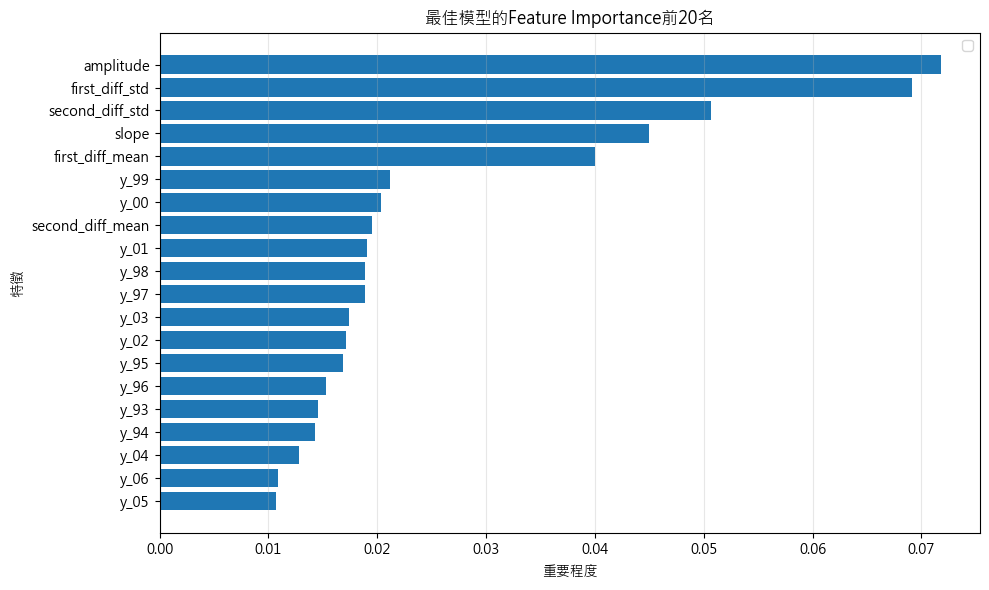

In [50]:
# 繪製圖表
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel("重要程度")
plt.ylabel("特徵")
plt.title("最佳模型的Feature Importance前20名")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(f'{DATA_DIR}/v1/feature_importance_results.png')
plt.show()

## 模型調參

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [52]:
# 調參前模型
baseline_model = joblib.load(f'{MODEL_DIR}/v1/best_model.joblib')
baseline_model.fit(X_train_math, y_train.reset_index(drop=True))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
baseline_train_pred = baseline_model.predict(X_train_math)
baseline_test_pred = baseline_model.predict(X_test_math)
baseline_train_acc = accuracy_score(y_train.reset_index(drop=True), baseline_train_pred)
baseline_test_acc = accuracy_score(y_test.reset_index(drop=True), baseline_test_pred)
print("模型調參前")
print(f"訓練數據準確度: {baseline_train_acc:.4f}")
print(f"測試數據準確度: {baseline_test_acc:.4f}")

模型調參前
訓練數據準確度: 1.0000
測試數據準確度: 0.6950


In [54]:
# 設定 GridSearchCV
rf_model = RandomForestClassifier(random_state=10)
param_grid = {'n_estimators': [100, 150, 200],
              'max_depth': [None, 10, 20],
              'min_samples_split': [2, 3, 5],
              'min_samples_leaf': [1]}

In [55]:
# 開始 GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_math, y_train.reset_index(drop=True))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [56]:
print(grid_search.best_params_)     # 最佳參數

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 150}


In [57]:
print(f"最佳CV準確度: {grid_search.best_score_:.4f}")

最佳CV準確度: 0.7116


In [58]:
# 使用最佳模型預測
best_model = grid_search.best_estimator_

In [59]:
train_pred = best_model.predict(X_train_math)
test_pred = best_model.predict(X_test_math)
train_accuracy = accuracy_score(y_train.reset_index(drop=True), train_pred)
test_accuracy = accuracy_score(y_test.reset_index(drop=True), test_pred)
print("模型調參後")
print(f"訓練數據準確度: {train_accuracy:.4f}")
print(f"測試數據準確度: {test_accuracy:.4f}")

模型調參後
訓練數據準確度: 0.9981
測試數據準確度: 0.7225


In [60]:
# 比較調參前後
print(f"調參前準確度: {baseline_test_acc:.4f}")
print(f"調參後準確度: {test_accuracy:.4f}")
improvement = test_accuracy - baseline_test_acc
print(f"改善幅度: {improvement:+.4f}")
print("結論:", end=" ")
if improvement > 0:
    print("模型調參後，測試準確度提升。")
elif improvement < 0:
    print("模型調參後，測試準確度下降。")
else:
    print("測試準確度沒有改變。\n")

調參前準確度: 0.6950
調參後準確度: 0.7225
改善幅度: +0.0275
結論: 模型調參後，測試準確度提升。


In [61]:
print(f"混淆矩陣:\n{confusion_matrix(y_test.reset_index(drop=True), test_pred)}")

混淆矩陣:
[[49  0  0  0  1  0  2 48]
 [ 0 96  4  0  0  0  0  0]
 [ 1  1 72 11 12  3  0  0]
 [ 0  0  0 63 30  0  5  2]
 [ 4  0  1 23 69  0  1  2]
 [ 0  0  2  4  9 85  0  0]
 [ 1  0  0  0  0  0 98  1]
 [50  0  0  0  2  0  2 46]]


In [62]:
print(f"分類報告:\n{classification_report(y_test.reset_index(drop=True), test_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.47      0.49      0.48       100
       cubic       0.99      0.96      0.97       100
 exponential       0.91      0.72      0.80       100
      linear       0.62      0.63      0.63       100
 logarithmic       0.56      0.69      0.62       100
   quadratic       0.97      0.85      0.90       100
  reciprocal       0.91      0.98      0.94       100
        sine       0.46      0.46      0.46       100

    accuracy                           0.72       800
   macro avg       0.74      0.72      0.73       800
weighted avg       0.74      0.72      0.73       800



In [63]:
# 儲存最佳模型
joblib.dump(best_model, f'{MODEL_DIR}/v1/best_model_tuned.joblib')

['d:\\Python\\我的AI作品集\\專案1_數學函數辨識\\Package\\models/v1/best_model_tuned.joblib']

## Ensemble

In [64]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

In [65]:
tuned = joblib.load(f'{MODEL_DIR}/v1/best_model_tuned.joblib')
tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [66]:
tuned_train_pred = tuned.predict(X_train)
tuned_test_pred = tuned.predict(X_test)
tuned_train_acc = accuracy_score(y_train, tuned_train_pred)
tuned_test_acc = accuracy_score(y_test, tuned_test_pred)

In [67]:
# 定義學習器
base_learners = [('DecisionTree', DecisionTreeClassifier(random_state=10)),
                 ('RandomForest', tuned)]
final_estimator = make_pipeline(StandardScaler(), 
                                SVC(random_state=10))

In [68]:
# 建立 Stacking Ensemble 模型
st_model = StackingClassifier(estimators=base_learners, final_estimator=final_estimator)
st_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('DecisionTree', ...), ('RandomForest', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",Pipeline(step...m_state=10))])
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, defau

In [69]:
ensemble_train_pred = st_model.predict(X_train)
ensemble_test_pred = st_model.predict(X_test)
ensemble_train_acc = accuracy_score(y_train, ensemble_train_pred)
ensemble_test_acc = accuracy_score(y_test, ensemble_test_pred)

In [70]:
print(f"訓練數據準確度: {ensemble_train_acc:.4f}")
print(f"測試數據準確度: {ensemble_test_acc:.4f}\n")

訓練數據準確度: 0.8881
測試數據準確度: 0.7063



In [71]:
print(f"混淆矩陣:\n{confusion_matrix(y_test, ensemble_test_pred)}")

混淆矩陣:
[[55  0  1  0  3  0 10 31]
 [ 0 95  3  0  0  2  0  0]
 [ 1  1 67 10 17  3  1  0]
 [ 4  0  0 64 25  0  6  1]
 [ 4  0  0 23 69  0  3  1]
 [ 0  1  5  2 10 82  0  0]
 [ 2  0  0  0  1  0 96  1]
 [53  0  0  0  2  0  8 37]]


In [72]:
print(f"分類報告:\n{classification_report(y_test, ensemble_test_pred)}")

分類報告:
              precision    recall  f1-score   support

      cosine       0.46      0.55      0.50       100
       cubic       0.98      0.95      0.96       100
 exponential       0.88      0.67      0.76       100
      linear       0.65      0.64      0.64       100
 logarithmic       0.54      0.69      0.61       100
   quadratic       0.94      0.82      0.88       100
  reciprocal       0.77      0.96      0.86       100
        sine       0.52      0.37      0.43       100

    accuracy                           0.71       800
   macro avg       0.72      0.71      0.71       800
weighted avg       0.72      0.71      0.71       800



In [73]:
# 實驗結果
print(f"模型調參前: {baseline_test_acc:.4f}")
print(f"模型調參後: {tuned_test_acc:.4f}")
print(f"Stacking Ensemble: {ensemble_test_acc:.4f}\n")

模型調參前: 0.6950
模型調參後: 0.6687
Stacking Ensemble: 0.7063



In [74]:
model_results = {'模型調參前': (baseline_test_acc, baseline_model),
                 '模型調參後': (tuned_test_acc, tuned),
                 'Stacking Ensemble': (ensemble_test_acc, st_model)}

In [75]:
best_model_name = max(model_results, key=lambda name: model_results[name][0])
best_accuracy, final_model = model_results[best_model_name]

In [76]:
print(f"最佳模型: {best_model_name} 模型")
print(f"準確度: {best_accuracy:.4f}\n")

最佳模型: Stacking Ensemble 模型
準確度: 0.7063



In [77]:
# 儲存最終模型
model_package = {'model': final_model,
                 'feature_names': X_train.columns.tolist()}
joblib.dump(model_package, f'{MODEL_DIR}/v1/final_model.joblib')

['d:\\Python\\我的AI作品集\\專案1_數學函數辨識\\Package\\models/v1/final_model.joblib']